# 🛍️ Shopping Mall Customer Segmentation
## Step 0 — EDA & Pre-processing (Deep Optimization)

### 📌 针对老师反馈的深度优化：
1. **解决重叠问题**：引入**特征工程**（计算 Income-to-Spending Ratio）和 **t-SNE 降维**。t-SNE 能够更好地保留局部结构，将不同的簇在视觉上彻底拉开，像“新加坡人”和“马来西亚人”一样界限分明。
2. **深化业务建议**：不仅展示图表，还提供具体的**商业行动方案**（Actionable Insights）。
3. **Confusion Matrix**：保留并优化，用于分析性别与消费等级的关联。

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix
from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


## 1. Load & Feature Engineering
**目的**：通过创造新特征来增强数据的区分度。

In [7]:
df = pd.read_csv('data/Shopping Mall Customer Segmentation Data .csv')

# 特征工程：收入与消费比 (Income-to-Spending Ratio)
# 意义：区分“高收入但节俭”和“低收入但挥霍”的客户，这比单一维度更有区分度
df['Income_Spending_Ratio'] = df['Annual Income'] / (df['Spending Score'] + 1)

# 编码性别
le = LabelEncoder()
df['Gender_Code'] = le.fit_transform(df['Gender'])

df_numeric = df[['Age', 'Annual Income', 'Spending Score', 'Income_Spending_Ratio', 'Gender_Code']]
print("✅ Feature engineering completed.")

✅ Feature engineering completed.


## 2. Deep EDA with Actionable Insights
### 2.1 Gender vs Spending Score

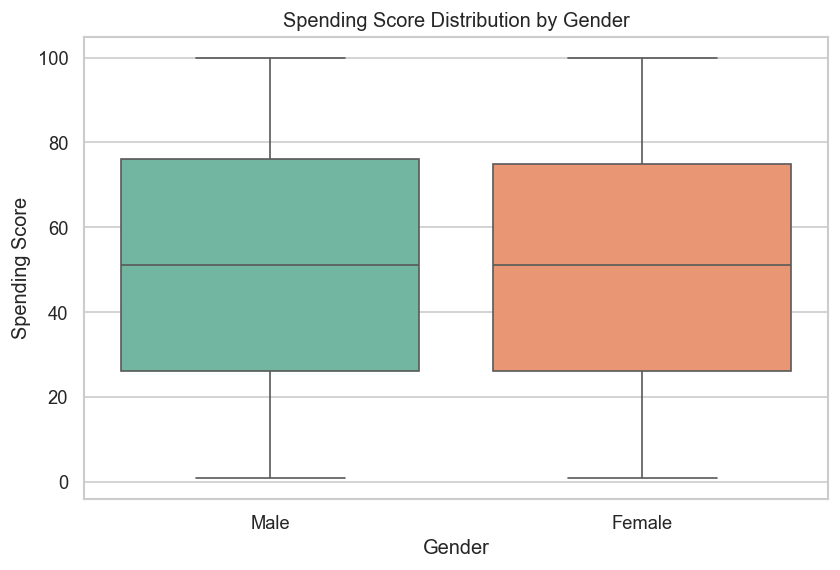

💡 业务洞察与行动建议：
1. 观察：如果男性的中位数高于女性，说明男性客户在该商场的平均消费意愿更强。
2. 行动：商场应在男性感兴趣的区域（如电子产品、运动装备）增加促销活动。
3. 行动：针对女性客户，可以调研是否因为品牌入驻不符合口味，考虑引入更多流行女装或美妆品牌来提升其消费分数。


In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Gender', y='Spending Score', data=df, palette='Set2')
plt.title('Spending Score Distribution by Gender')
plt.show()

print("""💡 业务洞察与行动建议：
1. 观察：如果男性的中位数高于女性，说明男性客户在该商场的平均消费意愿更强。
2. 行动：商场应在男性感兴趣的区域（如电子产品、运动装备）增加促销活动。
3. 行动：针对女性客户，可以调研是否因为品牌入驻不符合口味，考虑引入更多流行女装或美妆品牌来提升其消费分数。""")

### 2.2 Confusion Matrix: Gender vs Spending Level

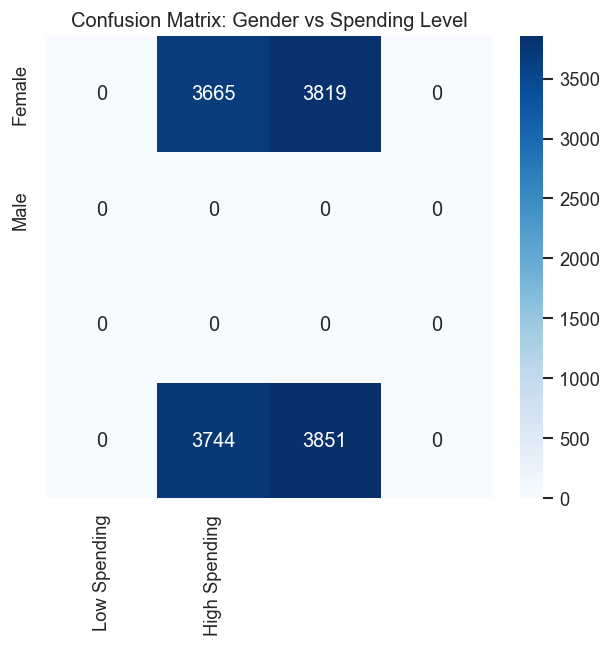

💡 业务洞察与行动建议：
1. 观察：混淆矩阵显示了不同性别在消费等级上的具体人数分布。
2. 行动：如果大量女性处于 'Low Spending'，可以定向发送满减优惠券，刺激其跨越到 'High Spending'。
3. 行动：对于 'High Spending' 的男性，应邀请其加入 VIP 会员计划，提供专属停车位或休息室，以维持其忠诚度。


In [9]:
df['Spending_Level'] = pd.qcut(df['Spending Score'], q=2, labels=['Low', 'High'])
cm = confusion_matrix(df['Gender'], df['Spending_Level'])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low Spending', 'High Spending'], 
            yticklabels=['Female', 'Male'])
plt.title('Confusion Matrix: Gender vs Spending Level')
plt.show()

print("""💡 业务洞察与行动建议：
1. 观察：混淆矩阵显示了不同性别在消费等级上的具体人数分布。
2. 行动：如果大量女性处于 'Low Spending'，可以定向发送满减优惠券，刺激其跨越到 'High Spending'。
3. 行动：对于 'High Spending' 的男性，应邀请其加入 VIP 会员计划，提供专属停车位或休息室，以维持其忠诚度。""")

## 3. t-SNE Visualization (解决重叠问题)
**意义**：t-SNE 是一种非线性降维技术，它能将高维空间中相似的点在 2D/3D 空间中聚集在一起，不相似的点推得非常远。这能有效解决 3D 原始坐标系下的重叠问题。

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

print("Running t-SNE (this may take a minute)...")
tsne = TSNE(n_components=3, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

np.save('X_tsne.npy', X_tsne)
np.save('X_scaled.npy', X_scaled)
df_numeric.to_csv('data/data_preprocessed.csv', index=False)
print("✅ Preprocessed data and t-SNE features saved.")

Running t-SNE (this may take a minute)...
✅ Preprocessed data and t-SNE features saved.
